In [1]:
from pathlib import Path
import sys

current_dir = Path.cwd()
parent_dir = current_dir.parent
sys.path.append(str(parent_dir))
#exp_path = r"F:\axonAtlas2\experiments\UTSW_brain6_reg_optim_2026-01-13_12-30-31"
#exp_path = r"Z:\anatomy_histology\volumetric_data_analysis\GPe_Single_neuron_reconstructions\GP_SWC_Files\CCFReg"
#exp_path = r"Z:\anatomy_histology\mouselight\gpe"
#target_directory = exp_path + "\dbscan_results"
target_directory = r"Z:\anatomy_histology\mouselight\STN_108"
exp_path = target_directory

In [2]:
from lib.swcAnalysis import *

f:\axonAtlas2\lib\swcAnalysis.py:38: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(swc_filepath, sep='\s+', comment='#', names=names, index_col='id', engine='python')


In [3]:
!pip install --upgrade --force-reinstall bg-atlasapi neurom pandas

  Using cached bg_atlasapi-1.0.3-py3-none-any.whl.metadata (12 kB)
  Using cached neurom-4.0.5-py3-none-any.whl
  Using cached pandas-3.0.2-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached brainglobe_space-1.0.3-py3-none-any.whl.metadata (8.0 kB)
  Using cached click-8.3.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached meshio-5.3.5-py3-none-any.whl.metadata (11 kB)
  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached treelib-1.8.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached morphio-3.4.2-cp312-cp312-win_amd64.whl.metadata (4.1 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached cached_property-2.0.1-py3-none-any.whl.metadata (10

error: uninstall-no-record-file

× Cannot uninstall packaging None
╰─> The package's contents are unknown: no RECORD file was found for packaging.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps packaging==25.0


In [4]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def cluster_axons_by_region_and_coords(csv_path, n_clusters=3):
    # 1. Load data
    df = pd.read_csv(csv_path)

    # 2. Create One-Hot Encoding for region names
    # This creates new columns like 'structure_name_Perireunensis nucleus'
    region_dummies = pd.get_dummies(df['structure_name'], prefix='region')
    df_encoded = pd.concat([df, region_dummies], axis=1)

    # 3. Prepare features for K-Means (Coordinates + One-Hot Regions)
    feature_cols = ['x', 'y', 'z'] + list(region_dummies.columns)
    features = df_encoded[feature_cols]

    # 4. Scale features
    # This is critical so that '1000 microns' isn't treated as 1000x more important than 'Region A'
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    # 5. Apply K-Means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    df_encoded['cluster_label'] = kmeans.fit_predict(features_scaled)

    # 6. Determine which Axon belongs to which Region
    # Count occurrences of each axon in each region
    counts = df.groupby(['swc_name', 'structure_name']).size().reset_index(name='point_count')
    
    # Assign axon to the region where it has the most coordinates
    assignments = counts.sort_values('point_count', ascending=False).drop_duplicates('swc_name')

    return df_encoded, assignments

# --- Usage ---
# df_with_clusters, final_results = cluster_axons_by_region_and_coords('your_file.csv')
# print(final_results)

In [5]:
# --- Usage ---
df_with_clusters, final_results = cluster_axons_by_region_and_coords("Z:\anatomy_histology\mouselight\gpe\swc_coordinate.csv")
print(final_results)

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_62168\666043716.py:2: SyntaxWarning: invalid escape sequence '\m'
  df_with_clusters, final_results = cluster_axons_by_region_and_coords("Z:\anatomy_histology\mouselight\gpe\swc_coordinate.csv")
C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_62168\666043716.py:2: SyntaxWarning: invalid escape sequence '\m'
  df_with_clusters, final_results = cluster_axons_by_region_and_coords("Z:\anatomy_histology\mouselight\gpe\swc_coordinate.csv")


OSError: [Errno 22] Invalid argument: 'Z:\x07natomy_histology\\mouselight\\gpe\\swc_coordinate.csv'

In [13]:

new_output_file_region = exp_path + "\swc_region_summary.csv" # This is the new file

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_31496\2810819673.py:1: SyntaxWarning: invalid escape sequence '\s'
  new_output_file_region = exp_path + "\swc_region_summary.csv" # This is the new file


In [15]:

import numpy as np
import pandas as pd
from pathlib import Path
import neurom as nm
from bg_atlasapi.bg_atlas import BrainGlobeAtlas

def calculate_metadata_with_bg_atlas(swc_directory, output_csv_file, atlas_name="allen_mouse_25um"):
    """
    Scans a directory of .swc files and calculates:
      - Total Length
      - Start Coordinates, Acronym, Full Name, & Hemisphere
      - End Coordinates, Acronym, Full Name, & Hemisphere
    """
    
    print(f"Initializing Brain Globe Atlas: '{atlas_name}'...")
    try:
        atlas = BrainGlobeAtlas(atlas_name)
    except Exception as e:
        print(f"Error initializing atlas. Is 'bg-atlasapi' installed?")
        print(f"Error details: {e}")
        return

    swc_dir_path = Path(swc_directory)
    swc_files = list(swc_dir_path.glob("*.swc"))
    
    if not swc_files:
        print(f"Error: No .swc files found in '{swc_directory}'.")
        return

    print(f"Found {len(swc_files)} .swc files. Extracting morphology data...")
    
    # Storage lists
    swc_filenames = []
    start_coords = []
    end_coords = []
    lengths = []
    
    for swc_file in swc_files:
        try:
            morph = nm.load_morphology(str(swc_file))
            
            # 1. Get Length
            total_len = nm.get('total_length', morph)
            if isinstance(total_len, (list, np.ndarray)):
                total_len = sum(total_len)
            
            # 2. Get Start Coordinate (Soma)
            soma_xyz = morph.points[0, :3] 
            
            # 3. Get End Coordinate (Farthest point from Soma)
            all_points = morph.points[:, :3]
            distances = np.linalg.norm(all_points - soma_xyz, axis=1)
            farthest_idx = np.argmax(distances)
            end_xyz = all_points[farthest_idx]
            
            # Append to lists
            swc_filenames.append(swc_file.name)
            lengths.append(total_len)
            start_coords.append(soma_xyz)
            end_coords.append(end_xyz)
            
        except Exception as e:
            print(f"  Warning: Could not load {swc_file.name}. Skipping. Error: {e}")

    n_samples = len(start_coords)
    if n_samples == 0:
        print("No valid data found.")
        return

    start_coords_arr = np.array(start_coords)
    end_coords_arr = np.array(end_coords)
    
    # Stack for atlas lookup
    combined_coords = np.vstack([start_coords_arr, end_coords_arr])

    # --- 3. Get Region and Hemisphere from Atlas ---
    print(f"Looking up {len(combined_coords)} coordinates (Start + End) in atlas...")
    
    acronyms = []
    full_names = []  # New list for full names
    hemispheres = []
    z_midpoint = (atlas.shape[2] * atlas.resolution[2]) / 2

    for coord in combined_coords:
        # A. Find Structure Info (ID -> Acronym + Name)
        try:
            # Get the ID first (microns=True for physical units)
            region_id = atlas.structure_from_coords(coord, microns=True)
            
            if region_id is not None and region_id > 0:
                # Look up details in the atlas dictionary
                struct_info = atlas.structures[region_id]
                acronym = struct_info['acronym']
                name = struct_info['name']
            else:
                acronym = "outside atlas"
                name = "outside atlas"
        except Exception:
            print(f"  Warning: Could not find structure for coordinate {coord}")
            #acronym = "outside_brain"
            #name = "outside_brain"
            
        acronyms.append(acronym)
        full_names.append(name)

        # B. Find Hemisphere
        if coord[2] < z_midpoint:
            hemispheres.append("Left")
        else:
            hemispheres.append("Right")

    # Split results back into Start and End
    start_acronyms = acronyms[:n_samples]
    end_acronyms = acronyms[n_samples:]
    
    start_names = full_names[:n_samples] # Split names
    end_names = full_names[n_samples:]
    
    start_hemispheres = hemispheres[:n_samples]
    end_hemispheres = hemispheres[n_samples:]

    # --- 4. Create Final DataFrame ---
    print("Assembling final DataFrame...")
    
    final_df = pd.DataFrame({
        "swc_name": swc_filenames,
        "length_um": lengths,
        
        # Start Metadata (Soma)
        "start_x": start_coords_arr[:, 0],
        "start_y": start_coords_arr[:, 1],
        "start_z": start_coords_arr[:, 2],
        "start_structure": start_acronyms,
        "start_structure_name": start_names, # New Column
        "start_hemisphere": start_hemispheres,
        
        # End Metadata (Tip)
        "end_x": end_coords_arr[:, 0],
        "end_y": end_coords_arr[:, 1],
        "end_z": end_coords_arr[:, 2],
        "end_structure": end_acronyms,
        "end_structure_name": end_names,     # New Column
        "end_hemisphere": end_hemispheres,
    })

    # Optional: Composite columns
    final_df['start_region_hemi'] = final_df['start_structure'].astype(str) + "_" + final_df['start_hemisphere']
    final_df['end_region_hemi'] = final_df['end_structure'].astype(str) + "_" + final_df['end_hemisphere']

    # --- 5. Save New CSV File ---
    try:
        final_df.to_csv(output_csv_file, index=False)
        print(f"\nSuccessfully created '{output_csv_file}' with {len(final_df)} entries.")
    except Exception as e:
        print(f"Error writing output file: {e}")

In [22]:

new_output_file_region = exp_path + "\swc_region_summary.csv" # This is the new file

# 2. Run the function
# We use 'allen_mouse_10um' as the atlas, which is standard
calculate_metadata_with_bg_atlas(target_directory, new_output_file_region, atlas_name="allen_mouse_25um")

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_31496\3165043429.py:1: SyntaxWarning: invalid escape sequence '\s'
  new_output_file_region = exp_path + "\swc_region_summary.csv" # This is the new file


Initializing Brain Globe Atlas: 'allen_mouse_25um'...
Found 108 .swc files. Extracting morphology data...
Looking up 216 coordinates (Start + End) in atlas...
Assembling final DataFrame...

Successfully created 'Z:\anatomy_histology\mouselight\STN_108\swc_region_summary.csv' with 108 entries.


In [6]:

new_output_file_coordinate = exp_path + "\swc_coordinate.csv" # This is the new file

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_49848\2199894197.py:1: SyntaxWarning: invalid escape sequence '\s'
  new_output_file_coordinate = exp_path + "\swc_coordinate.csv" # This is the new file


In [7]:

new_output_file_coordinate = exp_path + "\swc_coordinate.csv" # This is the new file

# 2. Run the function
# We use 'allen_mouse_10um' as the atlas, which is standard
generate_point_cloud_metadata(target_directory, new_output_file_coordinate, atlas_name="allen_mouse_25um")

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_49848\306625040.py:1: SyntaxWarning: invalid escape sequence '\s'
  new_output_file_coordinate = exp_path + "\swc_coordinate.csv" # This is the new file


Initializing Brain Globe Atlas: 'allen_mouse_25um'...
Found 31 .swc files. Extracting ALL points...

Total points to analyze: 373886
Starting atlas lookup... (This may take a while)
  Processed 373886/373886 points. Done.
Constructing final DataFrame...
Saving to 'Z:\anatomy_histology\mouselight\gpi\swc_coordinate.csv'...
Success! Saved 373886 rows.


In [9]:
import vedo
import os
import random
vedo.settings.default_backend = 'qt' # <-- Force 'qt' backend

from brainrender import Scene
from brainrender.actors import Neuron


dir = target_directory
all_file_paths = get_all_file_paths(dir)

scene = Scene(title="SWC Visualization") # <-- Note: jupyter=True is gone

for i in range(len(all_file_paths)):
    if all_file_paths[i].endswith('.swc'):
        print(f"Loading neuron {i} / {len(all_file_paths)} from: {all_file_paths[i]}")
        neuron = Neuron(
            all_file_paths[i],
            color=generate_random_rgb(),
            #color=colors[i],
            alpha=0.5
        )
        scene.add(neuron)


# This should now force a pop-up window
scene.render()

Loading neuron 0 / 33 from: Z:\anatomy_histology\mouselight\gpi\AA0215.swc
Loading neuron 1 / 33 from: Z:\anatomy_histology\mouselight\gpi\AA0250.swc
Loading neuron 2 / 33 from: Z:\anatomy_histology\mouselight\gpi\AA0284.swc
Loading neuron 3 / 33 from: Z:\anatomy_histology\mouselight\gpi\AA0330.swc
Loading neuron 4 / 33 from: Z:\anatomy_histology\mouselight\gpi\AA0435.swc
Loading neuron 5 / 33 from: Z:\anatomy_histology\mouselight\gpi\AA0583.swc
Loading neuron 6 / 33 from: Z:\anatomy_histology\mouselight\gpi\AA0587.swc
Loading neuron 7 / 33 from: Z:\anatomy_histology\mouselight\gpi\AA0617.swc
Loading neuron 8 / 33 from: Z:\anatomy_histology\mouselight\gpi\AA0764.swc
Loading neuron 9 / 33 from: Z:\anatomy_histology\mouselight\gpi\AA0852.swc
Loading neuron 10 / 33 from: Z:\anatomy_histology\mouselight\gpi\AA0882.swc
Loading neuron 11 / 33 from: Z:\anatomy_histology\mouselight\gpi\AA0992.swc
Loading neuron 12 / 33 from: Z:\anatomy_histology\mouselight\gpi\AA1046.swc
Loading neuron 13 / 33

In [9]:
all_file_paths


[
    'Z:\\anatomy_histology\\mouselight\\gpe\\AA1314.swc',
    'Z:\\anatomy_histology\\mouselight\\gpe\\AA1364.swc',
    'Z:\\anatomy_histology\\mouselight\\gpe\\AA1365.swc',
    'Z:\\anatomy_histology\\mouselight\\gpe\\AA1407.swc',
    'Z:\\anatomy_histology\\mouselight\\gpe\\AA1410.swc',
    'Z:\\anatomy_histology\\mouselight\\gpe\\AA1411.swc',
    'Z:\\anatomy_histology\\mouselight\\gpe\\AA1413.swc',
    'Z:\\anatomy_histology\\mouselight\\gpe\\AA1415.swc',
    'Z:\\anatomy_histology\\mouselight\\gpe\\AA1417.swc',
    'Z:\\anatomy_histology\\mouselight\\gpe\\swc_coordinate.csv',
    'Z:\\anatomy_histology\\mouselight\\gpe\\swc_region_summary.csv'
]

In [ ]:
import vedo
import os
import random
vedo.settings.default_backend = 'qt' # <-- Force 'qt' backend

from brainrender import Scene
from brainrender.actors import Neuron

def get_random_hex_color():
    """
    Generates a random hex color string (e.g. #FF0000).
    """
    return "#{:06x}".format(random.randint(0, 0xFFFFFF))

def get_all_file_paths(directory):
    file_paths = []
    for root, _, files in os.walk(directory):
        for file in files:
            file_paths.append(os.path.join(root, file))
    return file_paths

dir = target_directory
all_file_paths = get_all_file_paths(dir)
# use brighter colors for better visibility
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightgoldenrodyellow', 'plum', 'lightsalmon', 'lightseagreen', 'lightpink', 'lightgray']

scene = Scene(title="SWC Visualization") # <-- Note: jupyter=True is gone

# get top and side view (automate)
for i in range(len(all_file_paths)):
    if all_file_paths[i].endswith('.swc'):
        neuron = Neuron(
            all_file_paths[i],
            #color=colors[random.randint(0, len(colors)-1)],
            color=get_random_hex_color(),
            alpha=0.5
        )
        scene.add(neuron)
        print(f"Added neuron from: {all_file_paths[i]}")


# This should now force a pop-up window

# no region
scene.add_brain_region('GPe', alpha=0.1)
scene.render()

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
import matplotlib.patches as patches
import re
from bg_atlasapi import BrainGlobeAtlas
from collections import defaultdict

# --- Helper Functions ---

def _get_atlas_maps(atlas):
    """Generates depth maps from the atlas structure."""
    return {sid: len(info['structure_id_path']) for sid, info in atlas.structures.items()}

def print_hierarchy_tree(nodes, parent_acronym, atlas):
    """Prints a visual tree of the mapped regions for debugging."""
    print(f"\n[DEBUG] Hierarchical Tree for Parent: {parent_acronym}")
    try:
        parent_id = atlas.structures[parent_acronym]['id']
    except: return
    tree_struct = lambda: defaultdict(tree_struct)
    root = tree_struct()
    for node in nodes:
        struct = atlas.structures[node]
        path = struct['structure_id_path']
        if parent_id not in path: continue
        idx = path.index(parent_id)
        current_level = root
        for i in range(idx + 1, len(path)):
            struct_id = path[i]
            acronym = atlas.structures[struct_id]['acronym']
            current_level = current_level[acronym]
    def _display_tree(d, indent=0):
        for key in sorted(d.keys()):
            print("  " * indent + "└── " + str(key))
            _display_tree(d[key], indent + 1)
    _display_tree(root)

# --- Main Sankey Function ---

def sankey(csv_path, labels_csv_path=r"F:\axonAtlas2\labels.csv", parent_region='grey', max_depth=3, output_image='axon_sankey_hierarchical.png'):
    print(f"\n{'='*60}\nSTARTING ANATOMICAL SANKEY: Parent={parent_region}, Depth={max_depth}\n{'='*60}")

    # 1. Load Data
    df = pd.read_csv(csv_path)
    
    # 2. Consolidate Hemispheres (Summing Left/Right)
    print("[STEP 1] Consolidating Hemispheres...")
    def clean_acronym(name):
        return re.sub(r'(_left|_right|_[lL]|_[rR])$', '', str(name).strip(), flags=re.IGNORECASE)

    df['start_clean'] = df['start_region_hemi'].apply(clean_acronym)
    df['end_clean'] = df['end_region_hemi'].apply(clean_acronym)
    df_summed = df.groupby(['start_clean', 'end_clean'])['length_um'].sum().reset_index()

    # 3. Load Atlas & Resolve Parent Region
    atlas = BrainGlobeAtlas('allen_mouse_25um')
    depth_map = _get_atlas_maps(atlas)
    
    parent_struct = None
    if parent_region in atlas.structures:
        parent_struct = atlas.structures[parent_region]
    else:
        for s in atlas.structures.values():
            if str(s['acronym']).upper() == parent_region.upper():
                parent_struct = s; break
    
    if not parent_struct:
        print(f"[ERROR] Parent region '{parent_region}' not found."); return

    parent_id = parent_struct['id']
    parent_acronym = parent_struct['acronym']
    print(f"[SUCCESS] Parent resolved to: {parent_acronym} (ID: {parent_id})")

    # 4. Mapping Logic
    def get_mapped_acronym(acronym):
        try:
            struct = atlas.structures[acronym] if acronym in atlas.structures else None
            if not struct:
                for s in atlas.structures.values():
                    if s['acronym'].upper() == acronym.upper():
                        struct = s; break
            if not struct: return None
            path = struct['structure_id_path']
            if parent_id not in path: return None
            p_idx = path.index(parent_id)
            target_idx = p_idx + max_depth
            mapped_id = path[min(target_idx, len(path)-1)]
            return atlas.structures[mapped_id]['acronym']
        except: return None

    df_summed['start_mapped'] = df_summed['start_clean'].apply(get_mapped_acronym)
    df_summed['end_mapped'] = df_summed['end_clean'].apply(get_mapped_acronym)
    df_final = df_summed.dropna(subset=['start_mapped', 'end_mapped']).copy()
    df_final = df_final.groupby(['start_mapped', 'end_mapped'])['length_um'].sum().reset_index()

    if df_final.empty:
        print(f"[WARNING] No data found within {parent_acronym}.")
        return

    # 5. Robust Color Mapping from labels.csv
    print("[STEP 2] Matching line and node colors from labels.csv...")
    acronym_to_color = {}
    try:
        labels_df = pd.read_csv(labels_csv_path)
        # Pad hex values and ensure # prefix
        labels_df['color_hex_triplet'] = labels_df['color_hex_triplet'].astype(str).str.zfill(6)
        for _, row in labels_df.iterrows():
            acro_key = str(row['acronym']).lower()
            hex_val = "#" + str(row['color_hex_triplet']).replace("#", "")
            acronym_to_color[acro_key] = hex_val
    except Exception as e:
        print(f"[WARNING] Color lookup failed: {e}. Defaulting to grey.")

    unique_nodes = list(set(df_final['start_mapped'].unique()) | set(df_final['end_mapped'].unique()))
    print_hierarchy_tree(unique_nodes, parent_acronym, atlas)

    # 6. Plotting
    sorted_nodes = sorted(unique_nodes, key=lambda x: depth_map[atlas.structures[x]['id']])
    node_y = {node: 1 - (i + 1) / (len(sorted_nodes) + 1) for i, node in enumerate(sorted_nodes)}

    fig, ax = plt.subplots(figsize=(14, 12))
    total_val = df_final['length_um'].sum()

    for _, row in df_final.iterrows():
        s, t, val = row['start_mapped'], row['end_mapped'], row['length_um']
        x0, y0, x1, y1 = 0.25, node_y[s], 0.75, node_y[t]
        
        # --- COLOR CHANGE: Map color from the TARGET (t) instead of Source (s) ---
        line_color = acronym_to_color.get(t.lower(), "#808080")
        
        width = (np.log10(val + 1) / np.log10(total_val + 1)) * 45
        path = Path([(x0, y0), (x0 + 0.2, y0), (x1 - 0.2, y1), (x1, y1)], [1, 4, 4, 4])
        
        ax.add_patch(patches.PathPatch(path, facecolor='none', edgecolor=line_color, alpha=0.4, lw=width))

    for node, y in node_y.items():
        node_color = acronym_to_color.get(node.lower(), "#808080")
        ax.text(0.24, y, node, ha='right', va='center', fontsize=10, fontweight='bold', color=node_color)
        ax.plot(0.25, y, 'o', color=node_color, markersize=8)
        ax.text(0.76, y, node, ha='left', va='center', fontsize=10, fontweight='bold', color=node_color)
        ax.plot(0.75, y, 'o', color=node_color, markersize=8)

    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    plt.title(f'Anatomical Sankey: {parent_acronym} (Target-Colored Flows)', fontsize=16, pad=20)
    plt.tight_layout(); plt.savefig(output_image, dpi=300); plt.show()


STARTING ANATOMICAL SANKEY: Parent=grey, Depth=8
[STEP 1] Consolidating Hemispheres...
[SUCCESS] Parent resolved to: grey (ID: 8)
[STEP 2] Matching line and node colors from labels.csv...

[DEBUG] Hierarchical Tree for Parent: grey
└── BS
  └── IB
    └── HY
      └── MEZ
        └── PH
    └── TH
      └── DORpm
        └── MED
          └── PR
└── CH
  └── CNU
    └── STR
      └── STRd
        └── CP
  └── CTX
    └── CTXpl
      └── HPF
        └── HIP
          └── DG
            └── DG-po
      └── Isocortex
        └── ACA
          └── ACAv
            └── ACAv5
        └── MO
          └── MOp
            └── MOp1
          └── MOs
            └── MOs6a
        └── SS
          └── SSp
            └── SSp-bfd
              └── SSp-bfd5
            └── SSp-n
              └── SSp-n4
          └── SSs
            └── SSs6b
      └── OLF
        └── PIR
    └── CTXsp
      └── BLA
        └── BLAa


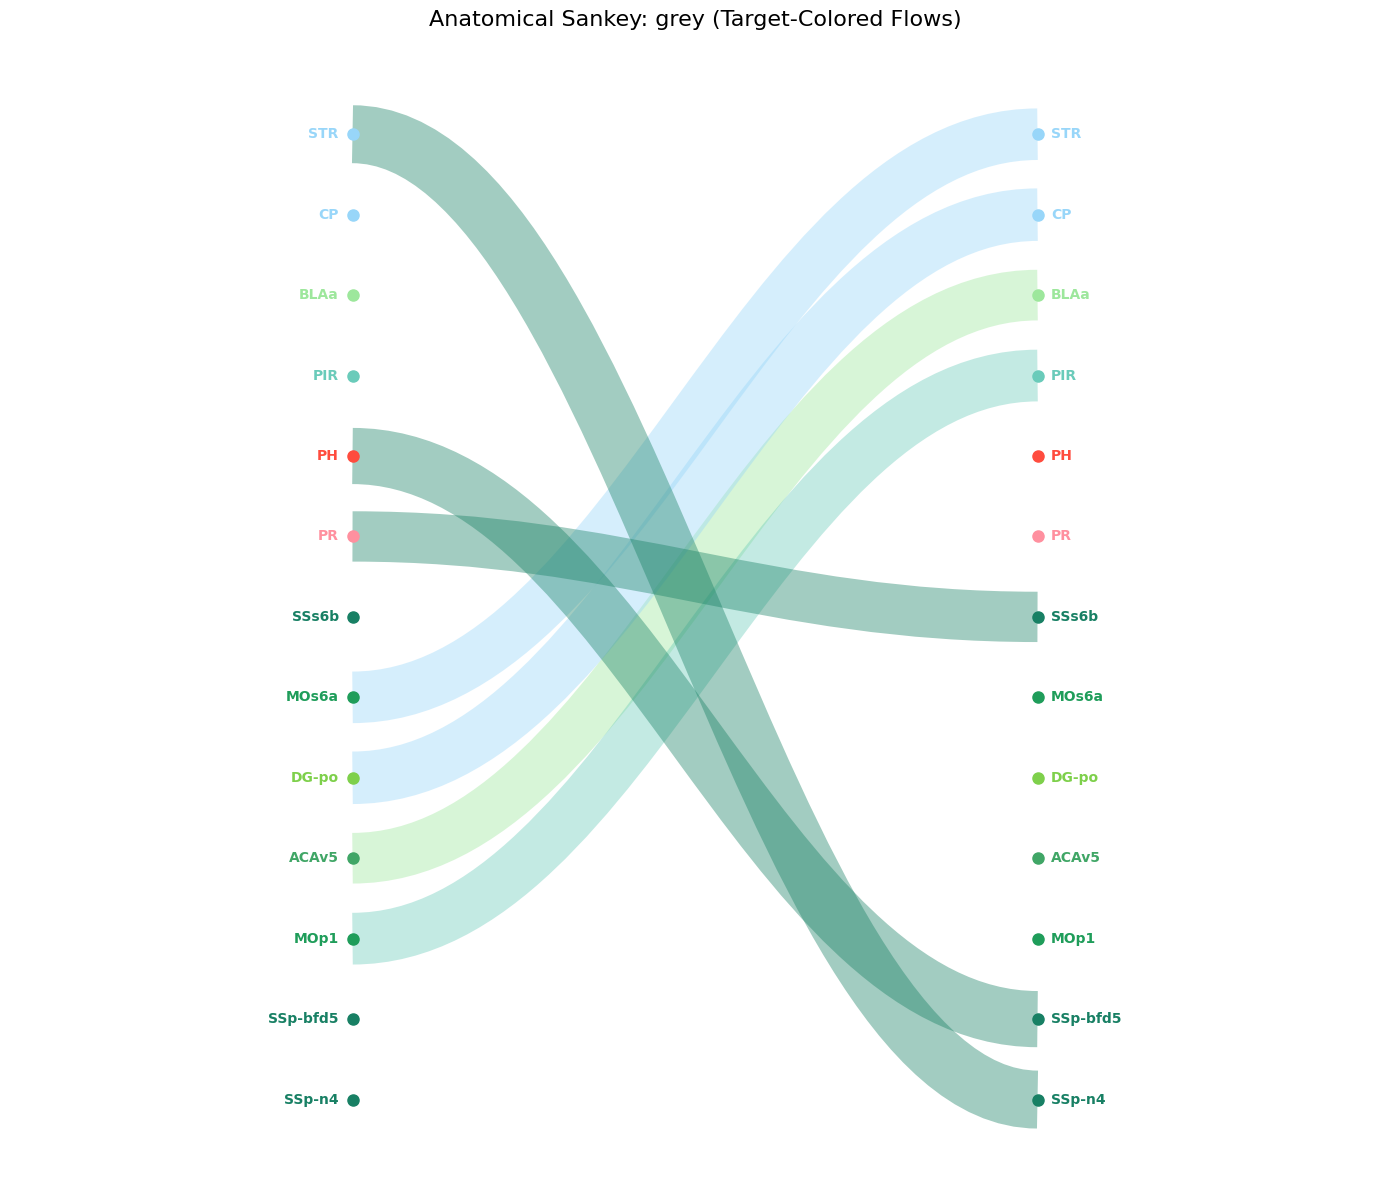

In [ ]:
sankey(new_output_file_region, parent_region= 'grey', max_depth=8,  labels_csv_path=r"F:\axonAtlas2\labels.csv")


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from brainglobe_atlasapi import BrainGlobeAtlas
from collections import defaultdict

# --- Helper Functions (As Requested) ---

def _get_atlas_maps(atlas):
    """Generates parent and depth maps from the atlas structure."""
    return {sid: len(info['structure_id_path']) for sid, info in atlas.structures.items()}

def print_hierarchy_tree(nodes, parent_acronym, atlas):
    """Prints a visual tree of the mapped regions for debugging."""
    print(f"\n[DEBUG] Hierarchical Tree for Parent: {parent_acronym}")
    try:
        parent_id = atlas.structures[parent_acronym]['id']
    except: return
    tree_struct = lambda: defaultdict(tree_struct)
    root = tree_struct()
    for node in nodes:
        if node not in atlas.structures: continue
        struct = atlas.structures[node]
        path = struct['structure_id_path']
        if parent_id not in path: continue
        idx = path.index(parent_id)
        current_level = root
        for i in range(idx + 1, len(path)):
            struct_id = path[i]
            acronym = atlas.structures[struct_id]['acronym']
            current_level = current_level[acronym]
    def _display_tree(d, indent=0):
        for key in sorted(d.keys()):
            print("  " * indent + "└── " + str(key))
            _display_tree(d[key], indent + 1)
    _display_tree(root)

# --- Main Occupancy Function ---

def plot_hierarchical_occupancy(
    csv_path, 
    labels_csv_path='labels.csv', 
    parent_region='grey', 
    max_depth=3, 
    output_image='hierarchical_occupancy.png'
):
    print(f"\n{'='*60}\nSTARTING HIERARCHICAL OCCUPANCY: Parent={parent_region}, Depth={max_depth}\n{'='*60}")

    # 1. Load Data
    df = pd.read_csv(csv_path)
    
    # Identify column names (handling variations like 'structure_name' or 'acronym')
    struct_col = 'structure_name' if 'structure_name' in df.columns else 'acronym'
    
    # 2. Consolidate Hemispheres logic from Sankey
    print("[STEP 1] Consolidating Hemispheres and Cleaning Acronyms...")
    def clean_acronym(name):
        return re.sub(r'(_left|_right|_[lL]|_[rR])$', '', str(name).strip(), flags=re.IGNORECASE)

    df['clean_acronym'] = df[struct_col].apply(clean_acronym)

    # 3. Load Atlas & Resolve Parent Region
    atlas = BrainGlobeAtlas('allen_mouse_25um')
    depth_map = _get_atlas_maps(atlas)
    
    parent_struct = None
    if parent_region in atlas.structures:
        parent_struct = atlas.structures[parent_region]
    else:
        for s in atlas.structures.values():
            if str(s['acronym']).upper() == parent_region.upper():
                parent_struct = s; break
    
    if not parent_struct:
        print(f"[ERROR] Parent region '{parent_region}' not found."); return

    parent_id = parent_struct['id']
    parent_acronym = parent_struct['acronym']

    # 4. Mapping Logic (Aggregation)
    def get_mapped_acronym(acronym):
        try:
            struct = atlas.structures[acronym] if acronym in atlas.structures else None
            if not struct:
                for s in atlas.structures.values():
                    if s['acronym'].upper() == acronym.upper():
                        struct = s; break
            if not struct: return None
            
            path = struct['structure_id_path']
            if parent_id not in path: return None
            
            p_idx = path.index(parent_id)
            target_idx = p_idx + max_depth
            mapped_id = path[min(target_idx, len(path)-1)]
            
            return atlas.structures[mapped_id]['acronym']
        except: return None

    print("[STEP 2] Mapping points to hierarchical parents...")
    df['mapped_region'] = df['clean_acronym'].apply(get_mapped_acronym)
    
    # Filter out points not under the parent hierarchy
    df_filtered = df.dropna(subset=['mapped_region']).copy()
    
    if df_filtered.empty:
        print(f"[WARNING] No data found within {parent_acronym} hierarchy.")
        return

    # 5. Calculate Occupancy based on Mapped Regions
    # Group by Axon (swc_name) and the new Mapped Region
    occupancy = df_filtered.groupby(['swc_name', 'mapped_region']).size().unstack(fill_value=0)
    
    # Normalize to get Percentage (%)
    occupancy_pct = occupancy.div(occupancy.sum(axis=1), axis=0) * 100

    # 6. Debug Tree and Color Sync from labels.csv
    unique_mapped = occupancy_pct.columns.tolist()
    print_hierarchy_tree(unique_mapped, parent_acronym, atlas)

    print("[STEP 3] Fetching colors for plot labels...")
    acronym_to_color = {}
    try:
        labels_df = pd.read_csv(labels_csv_path)
        labels_df['color_hex_triplet'] = labels_df['color_hex_triplet'].astype(str).str.zfill(6)
        for _, row in labels_df.iterrows():
            acronym_to_color[str(row['acronym']).lower()] = "#" + row['color_hex_triplet'].replace("#", "")
    except: pass

    # 7. Plotting
    # Sort columns by anatomical depth for a better heatmap layout
    sorted_cols = sorted(occupancy_pct.columns, key=lambda x: depth_map.get(atlas.structures[x]['id'], 0))
    occupancy_pct = occupancy_pct[sorted_cols]

    plt.figure(figsize=(18, 10))
    ax = sns.heatmap(occupancy_pct, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Axon Points in Region (%)'})
    
    # Apply custom colors to X-axis labels (the structures)
    for label in ax.get_xticklabels():
        text = label.get_text()
        color = acronym_to_color.get(text.lower(), "black")
        label.set_color(color)
        label.set_weight('bold')

    plt.title(f'Hierarchical Anatomical Occupancy: {parent_acronym} (Depth {max_depth})', fontsize=16)
    plt.xlabel('Mapped Brain Structure (Color-Synced)', fontsize=12)
    plt.ylabel('Axon ID', fontsize=12)
    
    

    plt.tight_layout()
    plt.savefig(output_image, dpi=300)
    print(f"[SUCCESS] Occupancy Heatmap saved to: {output_image}")
    plt.show()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from brainglobe_atlasapi import BrainGlobeAtlas
from collections import defaultdict

# --- Helper Functions (As Requested) ---

def _get_atlas_maps(atlas):
    """Generates depth maps from the atlas structure."""
    return {sid: len(info['structure_id_path']) for sid, info in atlas.structures.items()}

def print_hierarchy_tree(nodes, parent_acronym, atlas):
    """Prints a visual tree of the mapped regions for debugging."""
    print(f"\n[DEBUG] Hierarchical Tree for Parent: {parent_acronym}")
    try:
        parent_id = atlas.structures[parent_acronym]['id']
    except: return
    tree_struct = lambda: defaultdict(tree_struct)
    root = tree_struct()
    for node in nodes:
        if node not in atlas.structures: continue
        struct = atlas.structures[node]
        path = struct['structure_id_path']
        if parent_id not in path: continue
        idx = path.index(parent_id)
        current_level = root
        for i in range(idx + 1, len(path)):
            struct_id = path[i]
            acronym = atlas.structures[struct_id]['acronym']
            current_level = current_level[acronym]
    def _display_tree(d, indent=0):
        for key in sorted(d.keys()):
            print("  " * indent + "└── " + str(key))
            _display_tree(d[key], indent + 1)
    _display_tree(root)

# --- Main Occupancy Function ---

def plot_hierarchical_occupancy(csv_path, labels_csv_path='labels.csv', parent_region='grey', max_depth=3, output_image='hierarchical_occupancy.png'):
    print(f"\n{'='*60}\nSTARTING HIERARCHICAL OCCUPANCY: Parent={parent_region}, Depth={max_depth}\n{'='*60}")

    # 1. Load Data
    df = pd.read_csv(csv_path)
    
    # FIX: Robust Column Detection
    possible_cols = ['start_region_hemi', 'structure_name', 'acronym', 'region']
    struct_col = next((c for c in possible_cols if c in df.columns), None)
    
    if not struct_col:
        print(f"[ERROR] Could not find region column. Available columns: {df.columns.tolist()}")
        return

    # 2. Consolidate Hemispheres logic from Sankey
    print(f"[STEP 1] Using column '{struct_col}' for anatomical mapping...")
    def clean_acronym(name):
        return re.sub(r'(_left|_right|_[lL]|_[rR])$', '', str(name).strip(), flags=re.IGNORECASE)

    df['clean_acronym'] = df[struct_col].apply(clean_acronym)

    # 3. Load Atlas & Resolve Parent Region
    atlas = BrainGlobeAtlas('allen_mouse_25um')
    depth_map = _get_atlas_maps(atlas)
    
    parent_struct = None
    if parent_region in atlas.structures:
        parent_struct = atlas.structures[parent_region]
    else:
        for s in atlas.structures.values():
            if str(s['acronym']).upper() == parent_region.upper():
                parent_struct = s; break
    
    if not parent_struct:
        print(f"[ERROR] Parent region '{parent_region}' not found."); return

    parent_id = parent_struct['id']
    parent_acronym = parent_struct['acronym']
    print(f"[SUCCESS] Parent resolved to: {parent_acronym}")

    # 4. Mapping Logic (Aggregation)
    def get_mapped_acronym(acronym):
        try:
            struct = atlas.structures[acronym] if acronym in atlas.structures else None
            if not struct:
                for s in atlas.structures.values():
                    if s['acronym'].upper() == acronym.upper():
                        struct = s; break
            if not struct: return None
            
            path = struct['structure_id_path']
            if parent_id not in path: return None
            
            p_idx = path.index(parent_id)
            target_idx = p_idx + max_depth
            mapped_id = path[min(target_idx, len(path)-1)]
            
            return atlas.structures[mapped_id]['acronym']
        except: return None

    df['mapped_region'] = df['clean_acronym'].apply(get_mapped_acronym)
    df_filtered = df.dropna(subset=['mapped_region']).copy()
    
    if df_filtered.empty:
        print(f"[WARNING] No data found within {parent_acronym} hierarchy.")
        return

    # 5. Calculate Occupancy based on Mapped Regions
    # swc_name represents the individual axons
    occupancy = df_filtered.groupby(['swc_name', 'mapped_region']).size().unstack(fill_value=0)
    occupancy_pct = occupancy.div(occupancy.sum(axis=1), axis=0) * 100

    # 6. Color Mapping from labels.csv
    acronym_to_color = {}
    try:
        labels_df = pd.read_csv(labels_csv_path)
        labels_df['color_hex_triplet'] = labels_df['color_hex_triplet'].astype(str).str.zfill(6)
        for _, row in labels_df.iterrows():
            acronym_to_color[str(row['acronym']).lower()] = "#" + row['color_hex_triplet'].replace("#", "")
    except: pass

    # 7. Layout & Plotting
    unique_mapped = occupancy_pct.columns.tolist()
    print_hierarchy_tree(unique_mapped, parent_acronym, atlas)

    # Sort columns anatomically (by depth)
    sorted_cols = sorted(unique_mapped, key=lambda x: depth_map.get(atlas.structures[x]['id'], 0))
    occupancy_pct = occupancy_pct[sorted_cols]

    plt.figure(figsize=(18, 10))
    ax = sns.heatmap(occupancy_pct, cmap='YlGnBu', cbar_kws={'label': 'Axon Volume in Region (%)'})
    
    # Sync label colors with labels.csv
    for label in ax.get_xticklabels():
        text = label.get_text()
        label.set_color(acronym_to_color.get(text.lower(), "black"))
        label.set_weight('bold')

    plt.title(f'Hierarchical Anatomical Occupancy: {parent_acronym} (Max Depth {max_depth})', fontsize=16)
    plt.tight_layout()
    plt.savefig(output_image, dpi=300)
    plt.show()

    return occupancy_pct
    return occupancy_pct
    



STARTING HIERARCHICAL OCCUPANCY: Parent=grey, Depth=10
[STEP 1] Using column 'start_region_hemi' for anatomical mapping...
[SUCCESS] Parent resolved to: grey

[DEBUG] Hierarchical Tree for Parent: grey


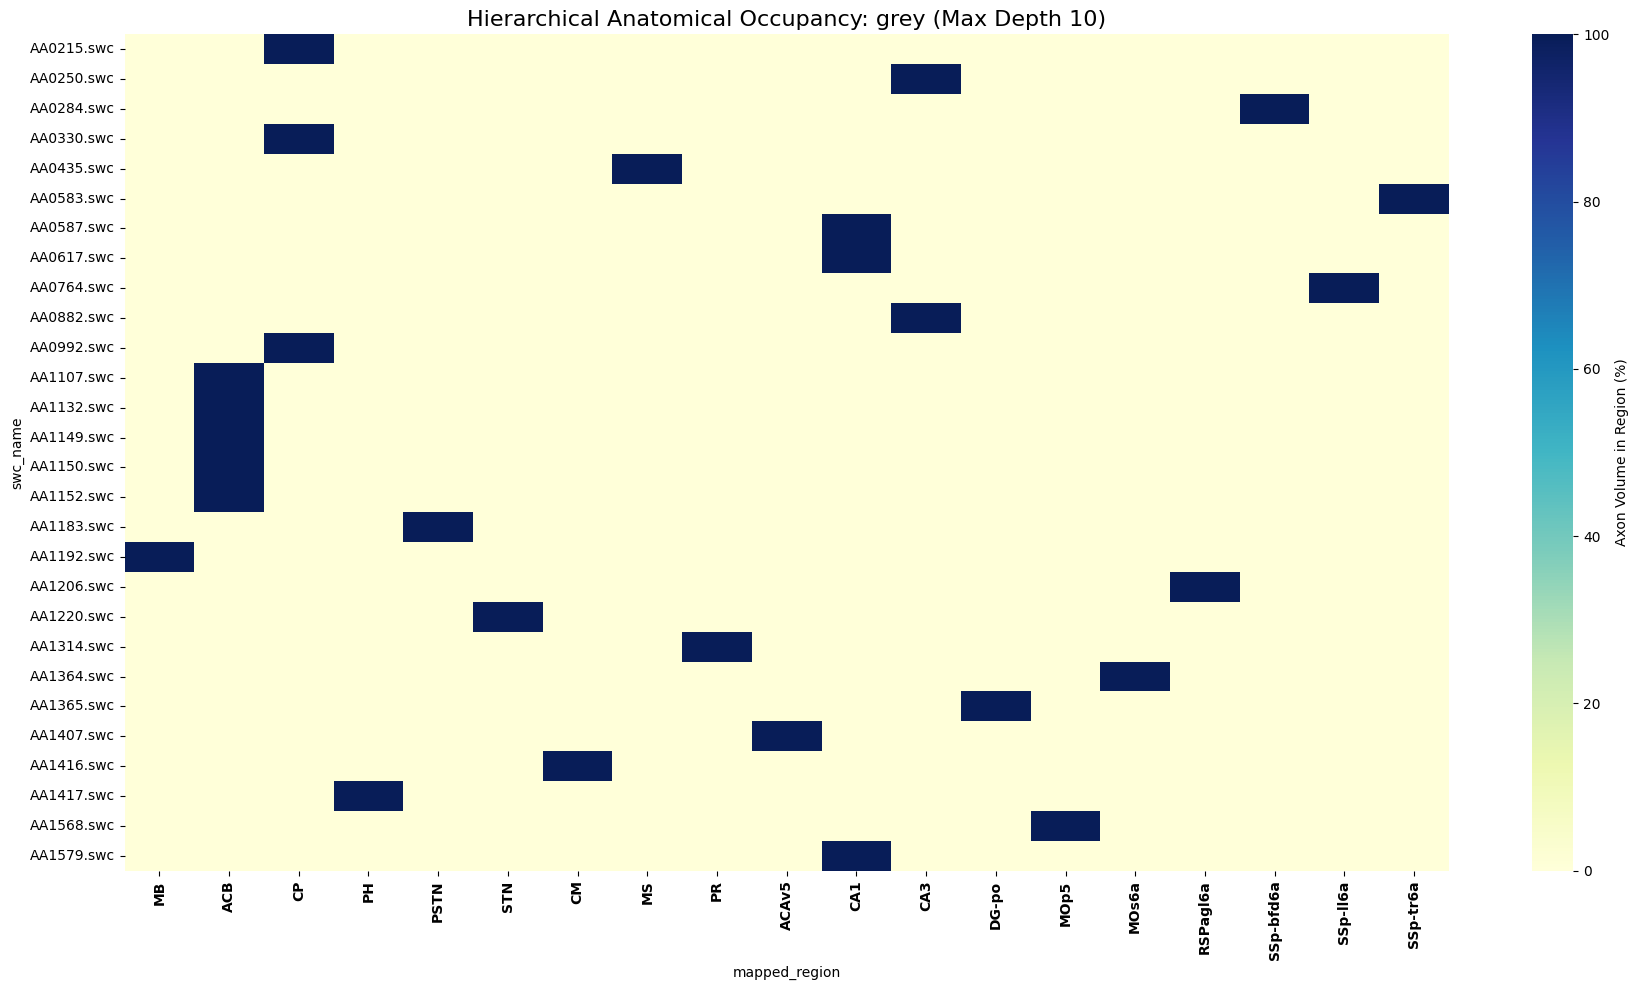

mapped_region,MB,ACB,CP,PH,PSTN,STN,CM,MS,PR,ACAv5,CA1,CA3,DG-po,MOp5,MOs6a,RSPagl6a,SSp-bfd6a,SSp-ll6a,SSp-tr6a
swc_name,,,,,,,,,,,,,,,,,,,
AA0215.swc,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AA0250.swc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AA0284.swc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
AA0330.swc,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AA0435.swc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AA0583.swc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
AA0587.swc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AA0617.swc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AA0764.swc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0


In [11]:
plot_hierarchical_occupancy(new_output_file_region, max_depth=10)


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import re
from brainglobe_atlasapi import BrainGlobeAtlas
from collections import defaultdict

# --- Helper Functions (Integrated from Sankey) ---

def _get_atlas_maps(atlas):
    """Generates parent and depth maps from the atlas structure."""
    return {sid: len(info['structure_id_path']) for sid, info in atlas.structures.items()}

def print_hierarchy_tree(nodes, parent_acronym, atlas):
    """Prints a visual tree of the mapped regions for debugging."""
    print(f"\n[DEBUG] Hierarchical Tree for Parent: {parent_acronym}")
    try:
        parent_id = atlas.structures[parent_acronym]['id']
    except: return
    tree_struct = lambda: defaultdict(tree_struct)
    root = tree_struct()
    for node in nodes:
        if node not in atlas.structures: continue
        struct = atlas.structures[node]
        path = struct['structure_id_path']
        if parent_id not in path: continue
        idx = path.index(parent_id)
        current_level = root
        for i in range(idx + 1, len(path)):
            struct_id = path[i]
            acronym = atlas.structures[struct_id]['acronym']
            current_level = current_level[acronym]
    def _display_tree(d, indent=0):
        for key in sorted(d.keys()):
            print("  " * indent + "└── " + str(key))
            _display_tree(d[key], indent + 1)
    _display_tree(root)

# --- Main Barcode Function ---

def create_hierarchical_barcode(
    coord_csv, 
    labels_csv_path=r"F:\axonAtlas2\labels.csv", 
    parent_region='grey', 
    max_depth=3, 
    num_bins=100,
    output_image='hierarchical_structure_barcode.png'
):
    print(f"\n{'='*60}\nSTARTING HIERARCHICAL BARCODE: Parent={parent_region}, Depth={max_depth}\n{'='*60}")

    # 1. Load Data
    df = pd.read_csv(coord_csv)
    
    # 2. Robust Column Detection (Updated to include 'structure')
    possible_cols = ['structure', 'structure_name', 'acronym', 'start_region_hemi', 'region']
    struct_col = next((c for c in possible_cols if c in df.columns), None)
    if not struct_col:
        print(f"[ERROR] Could not find region column. Available columns: {df.columns.tolist()}")
        return

    # 3. Load Atlas & Resolve Parent
    atlas = BrainGlobeAtlas('allen_mouse_25um')
    depth_map = _get_atlas_maps(atlas)
    
    parent_struct = None
    for s in atlas.structures.values():
        if str(s['acronym']).upper() == parent_region.upper():
            parent_struct = s; break
    if not parent_struct:
        print(f"[ERROR] Parent region '{parent_region}' not found."); return
    parent_id = parent_struct['id']

    # 4. Mapping Logic (Point-by-Point Hierarchy)
    def clean_acronym(name):
        return re.sub(r'(_left|_right|_[lL]|_[rR])$', '', str(name).strip(), flags=re.IGNORECASE)

    def get_mapped_acronym(raw_name):
        acronym = clean_acronym(raw_name)
        try:
            struct = atlas.structures[acronym] if acronym in atlas.structures else None
            if not struct:
                for s in atlas.structures.values():
                    if s['acronym'].upper() == acronym.upper():
                        struct = s; break
            if not struct: return "Unknown"
            
            path = struct['structure_id_path']
            if parent_id not in path: return "Outside Hierarchy"
            
            p_idx = path.index(parent_id)
            target_idx = p_idx + max_depth
            mapped_id = path[min(target_idx, len(path)-1)]
            return atlas.structures[mapped_id]['acronym']
        except: return "Unknown"

    print(f"[STEP 1] Mapping individual points from '{struct_col}' to hierarchy...")
    df['mapped_region'] = df[struct_col].apply(get_mapped_acronym)
    
    # 5. Load Official Colors from labels.csv
    print("[STEP 2] Loading official colors from labels.csv...")
    acronym_to_color = {"Unknown": "#808080", "Outside Hierarchy": "#FFFFFF"}
    try:
        labels_df = pd.read_csv(labels_csv_path)
        labels_df['color_hex_triplet'] = labels_df['color_hex_triplet'].astype(str).str.zfill(6)
        for _, row in labels_df.iterrows():
            acro_key = str(row['acronym']).lower()
            hex_val = "#" + row['color_hex_triplet'].replace("#", "")
            acronym_to_color[acro_key] = hex_val
    except Exception as e:
        print(f"[WARNING] Color load failed: {e}. Defaulting to grey.")

    # 6. Prepare Barcode Matrix
    all_axons = sorted(df['swc_name'].unique())
    unique_mapped = sorted([n for n in df['mapped_region'].unique() if n not in ["Unknown", "Outside Hierarchy"]])
    
    # Print Debug Tree (Uses helper method)
    print_hierarchy_tree(unique_mapped, parent_struct['acronym'], atlas)

    barcode_data = np.zeros((len(all_axons), num_bins))
    struct_list = ["Outside Hierarchy", "Unknown"] + unique_mapped
    struct_to_id = {name: i for i, name in enumerate(struct_list)}
    
    for i, axon_name in enumerate(all_axons):
        axon_subset = df[df['swc_name'] == axon_name].reset_index(drop=True)
        num_points = len(axon_subset)
        if num_points == 0: continue
        
        for b in range(num_bins):
            idx = int((b / num_bins) * num_points)
            mapped_name = axon_subset.loc[idx, 'mapped_region']
            barcode_data[i, b] = struct_to_id.get(mapped_name, 1)

    # 7. Rendering with Sync Colors
    fig, ax = plt.subplots(figsize=(15, len(all_axons) * 0.4 + 2))
    
    # Build colormap from labels.csv colors
    final_colors = [acronym_to_color.get(name.lower(), "#808080") for name in struct_list]
    custom_cmap = ListedColormap(final_colors)

    ax.imshow(barcode_data, aspect='auto', cmap=custom_cmap, interpolation='nearest')

    # Formatting
    ax.set_yticks(range(len(all_axons)))
    ax.set_yticklabels(all_axons)
    ax.set_xticks(np.linspace(0, num_bins-1, 11))
    ax.set_xticklabels([f'{int(x)}%' for x in np.linspace(0, 100, 11)])
    ax.set_title(f'Hierarchical Structure Transitions: {parent_struct["acronym"]} (Depth {max_depth})', fontsize=16)
    ax.set_xlabel('Progression along Axon Path (%)', fontsize=12)

    # Legend (Shows official colors)
    legend_patches = [mpatches.Patch(color=final_colors[i], label=name) 
                     for i, name in enumerate(struct_list) if name != "Outside Hierarchy"]
    ax.legend(handles=legend_patches, title='Mapped Structures', bbox_to_anchor=(1.01, 1), 
              loc='upper left', fontsize='x-small', ncol=1)

    plt.tight_layout()
    plt.savefig(output_image, dpi=300)
    print(f"[SUCCESS] Hierarchical Barcode saved to: {output_image}")
    plt.show()

# Execution Example
# create_hierarchical_barcode('swc_coordinate.csv', parent_region='grey', max_depth=3)


STARTING HIERARCHICAL BARCODE: Parent=grey, Depth=6
[STEP 1] Mapping individual points from 'structure' to hierarchy...
[STEP 2] Loading official colors from labels.csv...

[DEBUG] Hierarchical Tree for Parent: grey


C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_34176\2348667283.py:158: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


[SUCCESS] Hierarchical Barcode saved to: hierarchical_structure_barcode.png


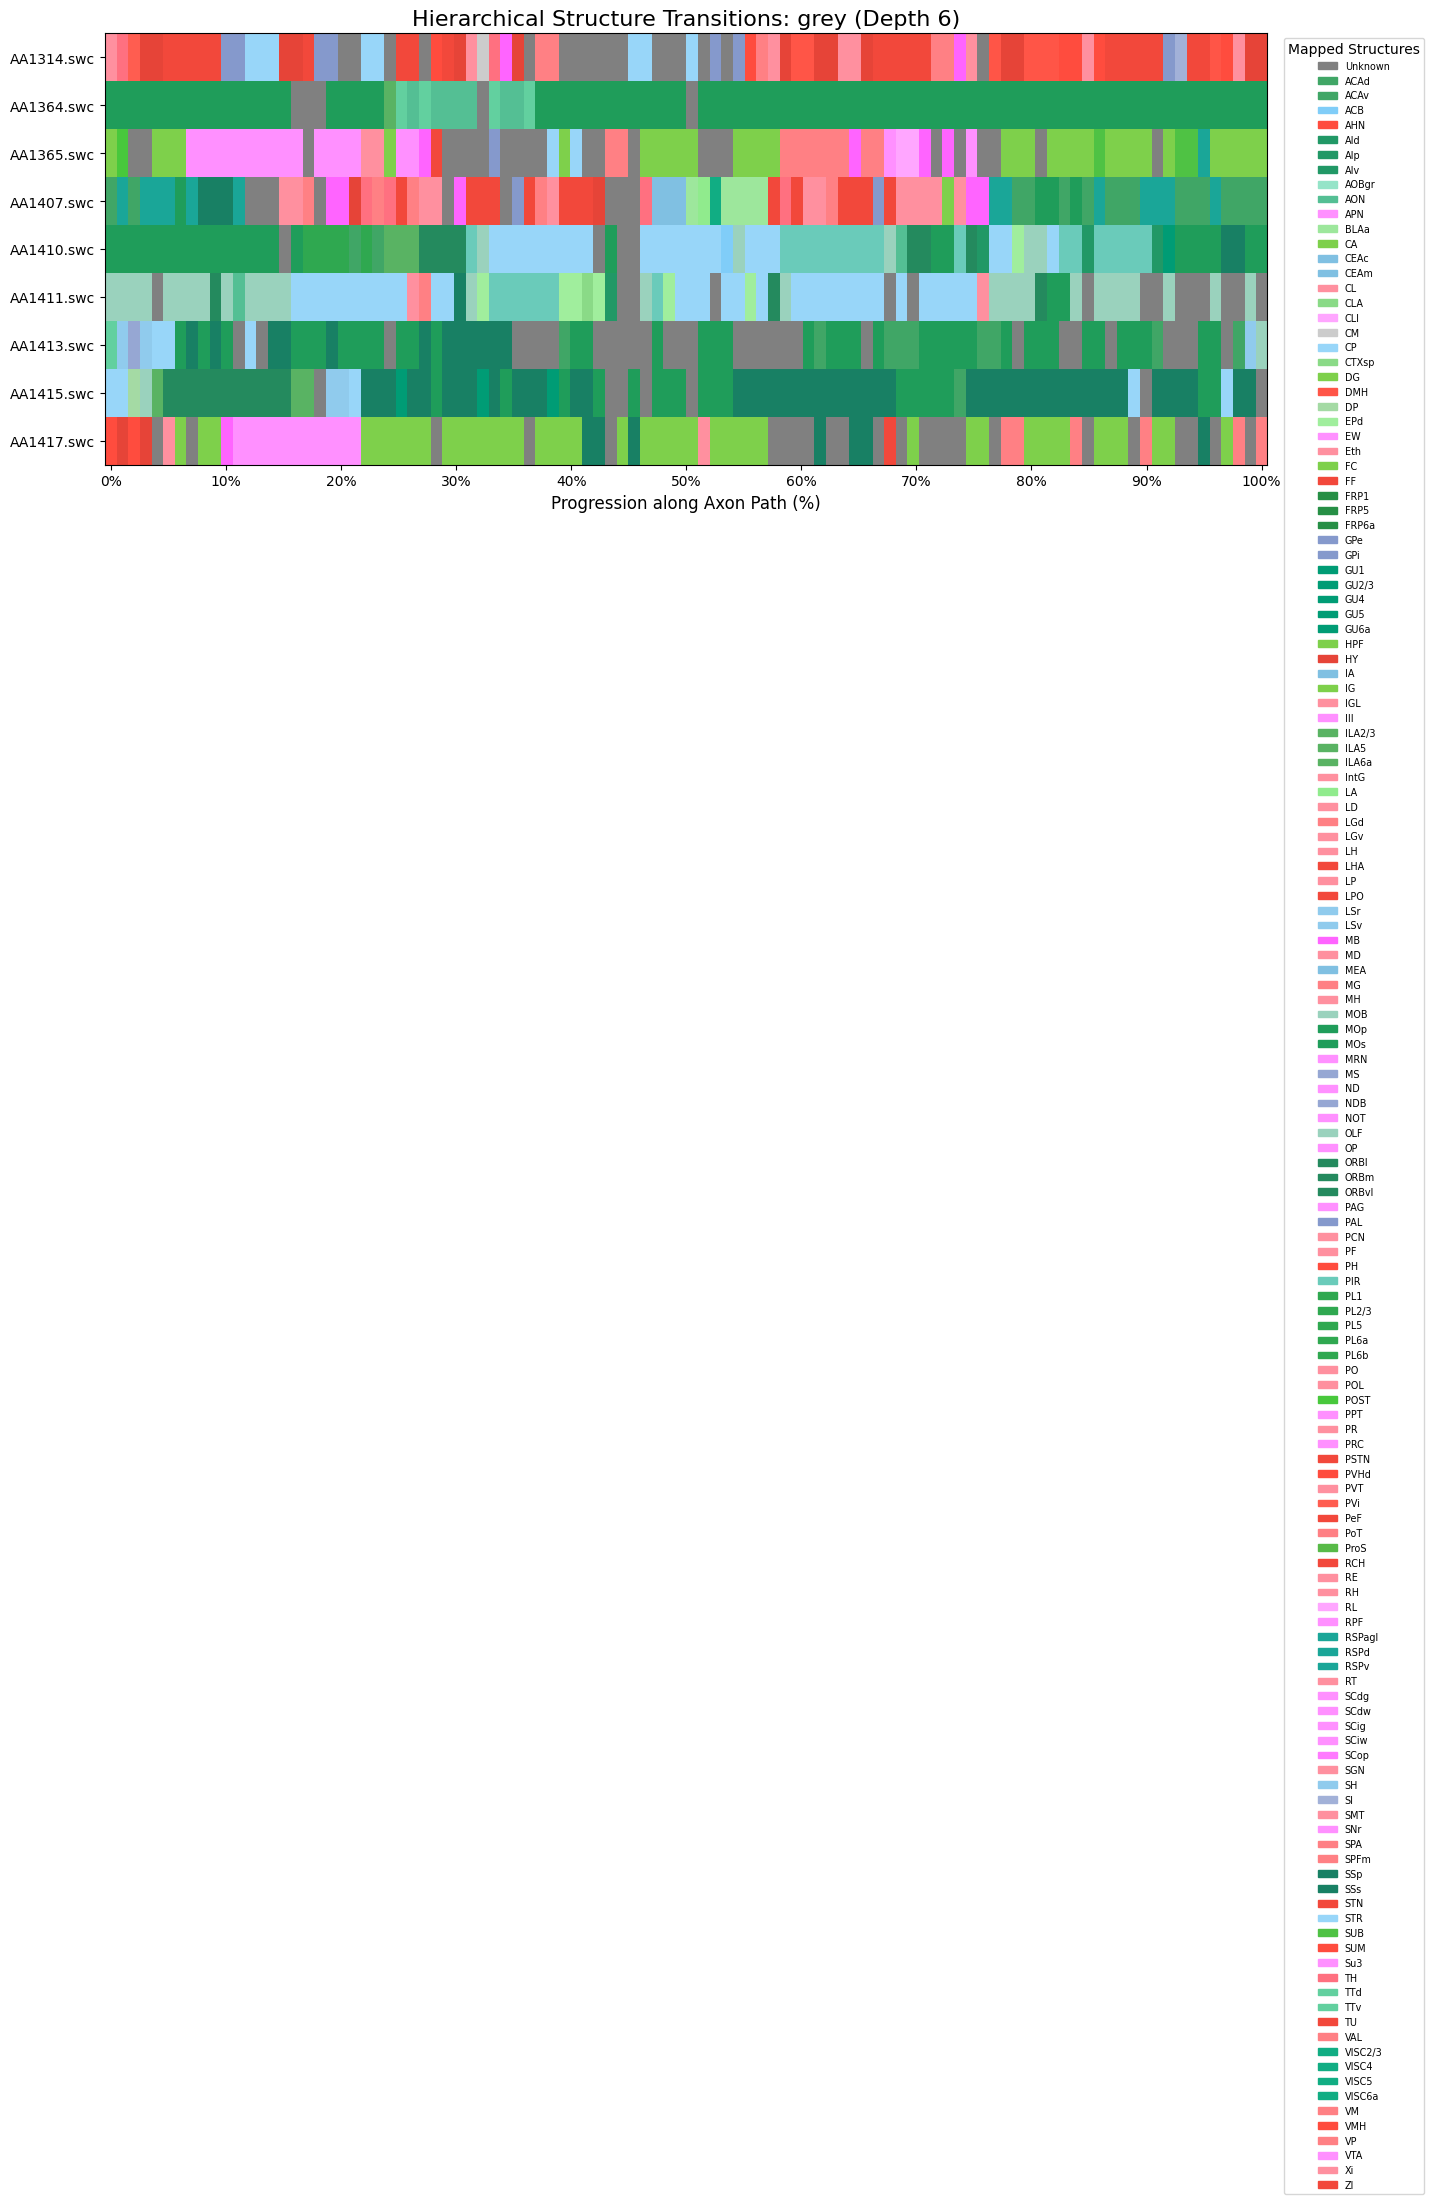

In [17]:
create_hierarchical_barcode(new_output_file_coordinate, max_depth=6)

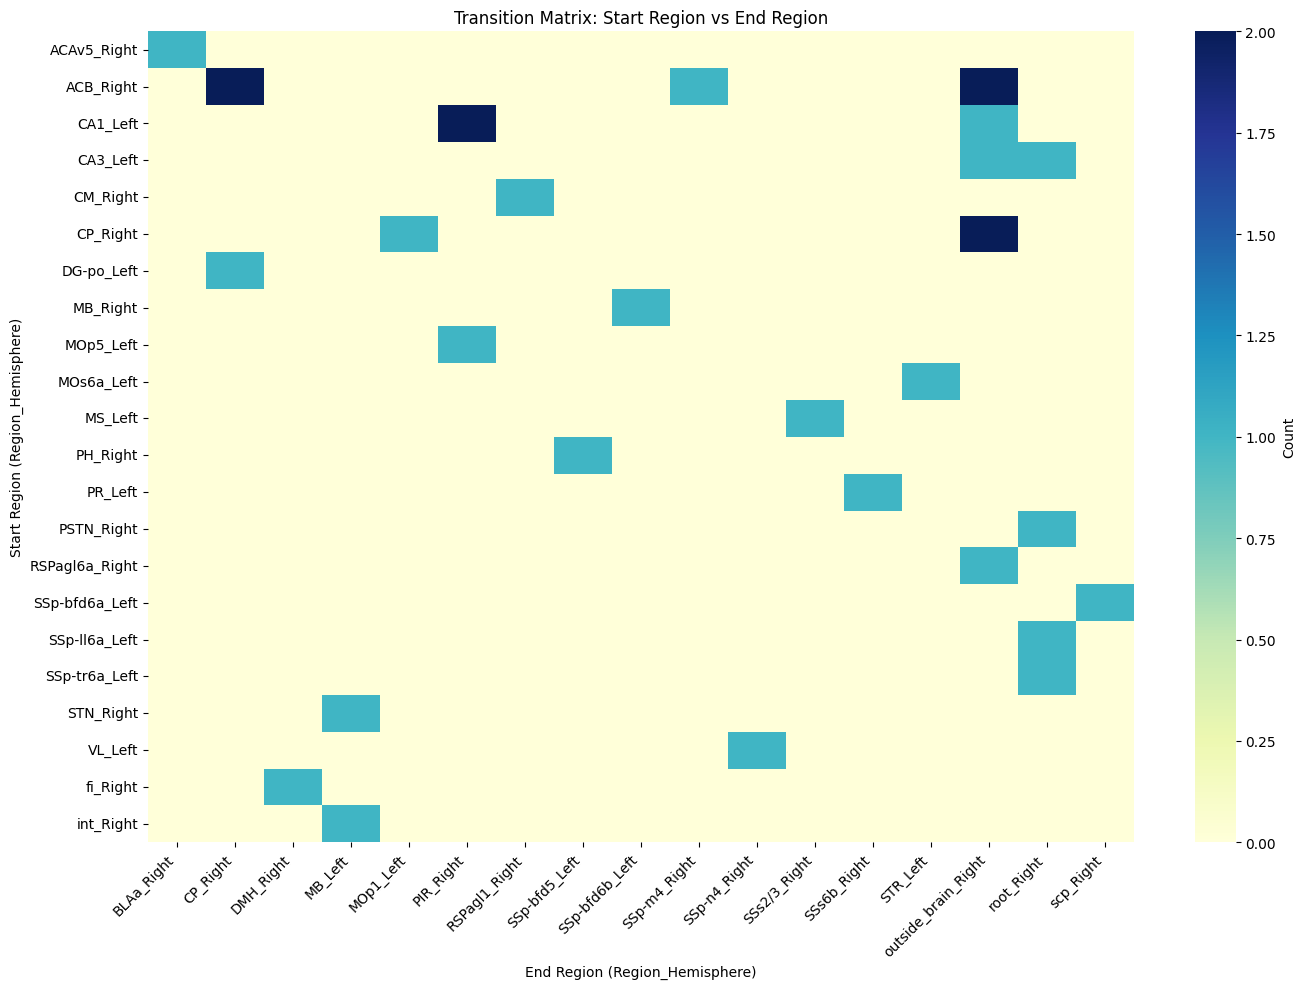

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv(new_output_file_region)

# Create the transition matrix (counts)
transition_matrix = pd.crosstab(df['start_region_hemi'], df['end_region_hemi'])

# Create the heatmap plot without numbers
plt.figure(figsize=(14, 10))
sns.heatmap(
    transition_matrix, 
    annot=False,    # This removes the numbers from the cells
    cmap='YlGnBu', 
    cbar_kws={'label': 'Count'}
)

plt.title('Transition Matrix: Start Region vs End Region')
plt.xlabel('End Region (Region_Hemisphere)')
plt.ylabel('Start Region (Region_Hemisphere)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the updated plot
plt.savefig('transition_matrix_heatmap_no_numbers.png')

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from brainglobe_atlasapi import BrainGlobeAtlas

def create_hierarchical_transition_matrix(
    coord_csv, 
    parent_region='grey', 
    max_depth=10, 
    output_image='hierarchical_transition_heatmap.png',
    cmap = 'YlGnBu'
):
    print(f"--- Generating Hierarchical Transition Matrix (Depth: {max_depth}) ---")
    
    # 1. Load Data
    df = pd.read_csv(coord_csv)
    
    # 2. Robust Column Detection (Identical to your barcode script)
    possible_cols = ['structure', 'structure_name', 'acronym', 'start_region_hemi', 'region']
    struct_col = next((c for c in possible_cols if c in df.columns), None)
    
    if not struct_col:
        print(f"[ERROR] Could not find region column. Available: {df.columns.tolist()}")
        return

    # 3. Load Atlas & Resolve Parent
    atlas = BrainGlobeAtlas('allen_mouse_25um')
    parent_struct = next((s for s in atlas.structures.values() 
                          if str(s['acronym']).upper() == parent_region.upper()), None)
    
    if not parent_struct:
        print(f"[ERROR] Parent region '{parent_region}' not found.")
        return
    parent_id = parent_struct['id']

    # 4. Hierarchy Mapping Logic (Identical to your barcode script)
    def clean_acronym(name):
        # This removes _left, _right, etc. to match atlas acronyms
        return re.sub(r'(_left|_right|_[lL]|_[rR])$', '', str(name).strip(), flags=re.IGNORECASE)

    def get_mapped_acronym(raw_name):
        acronym = clean_acronym(raw_name)
        try:
            struct = atlas.structures[acronym] if acronym in atlas.structures else None
            if not struct:
                # Fallback search
                for s in atlas.structures.values():
                    if s['acronym'].upper() == acronym.upper():
                        struct = s; break
            if not struct: return "Unknown"
            
            path = struct['structure_id_path']
            if parent_id not in path: return "Outside Hierarchy"
            
            p_idx = path.index(parent_id)
            target_idx = p_idx + max_depth
            mapped_id = path[min(target_idx, len(path)-1)]
            return atlas.structures[mapped_id]['acronym']
        except:
            return "Unknown"

    # Apply mapping to every coordinate
    print(f"Mapping coordinates from column: {struct_col}...")
    df['mapped_region'] = df[struct_col].apply(get_mapped_acronym)

    # 5. Identify Crossings (Transitions)
    # Compare each point to the next point within the same axon (swc_name)
    df['next_region'] = df.groupby('swc_name')['mapped_region'].shift(-1)

    # Filter for actual boundary crossings
    crossings = df[
        (df['next_region'].notna()) & 
        (df['mapped_region'] != df['next_region'])
    ].copy()

    # 6. Create Probability Matrix
    # Get raw counts of crossings from Source to Destination
    transition_counts = pd.crosstab(crossings['mapped_region'], crossings['next_region'])
    
    # Convert to Probability: P(Next | Current)
    # We divide each row by the sum of that row. Each row now sums to 1.0.
    transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0).fillna(0)

    # 7. Rendering the Heatmap (No Numbers)
    plt.figure(figsize=(16, 14))
    sns.heatmap(
        transition_probs, 
        annot=False,  # Numbers hidden as requested
        cmap=cmap,
        cbar_kws={'label': 'Transition Probability'}
    )

    plt.title(f'Hierarchical Transition Probability (Depth {max_depth})\nParent: {parent_region}', fontsize=16)
    plt.xlabel('Destination Region (To)', fontsize=12)
    plt.ylabel('Source Region (From)', fontsize=12)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    
    # Save the files
    plt.savefig(output_image, dpi=300)
    transition_probs.to_csv('hierarchical_transition_probabilities.csv')
    
    print(f"[SUCCESS] Matrix created with {len(transition_probs)} unique regions.")
    print(f"Files saved: {output_image} and hierarchical_transition_probabilities.csv")


--- Generating Hierarchical Transition Matrix (Depth: 10) ---
Mapping coordinates from column: structure...
[SUCCESS] Matrix created with 48 unique regions.
Files saved: hierarchical_transition_heatmap.png and hierarchical_transition_probabilities.csv


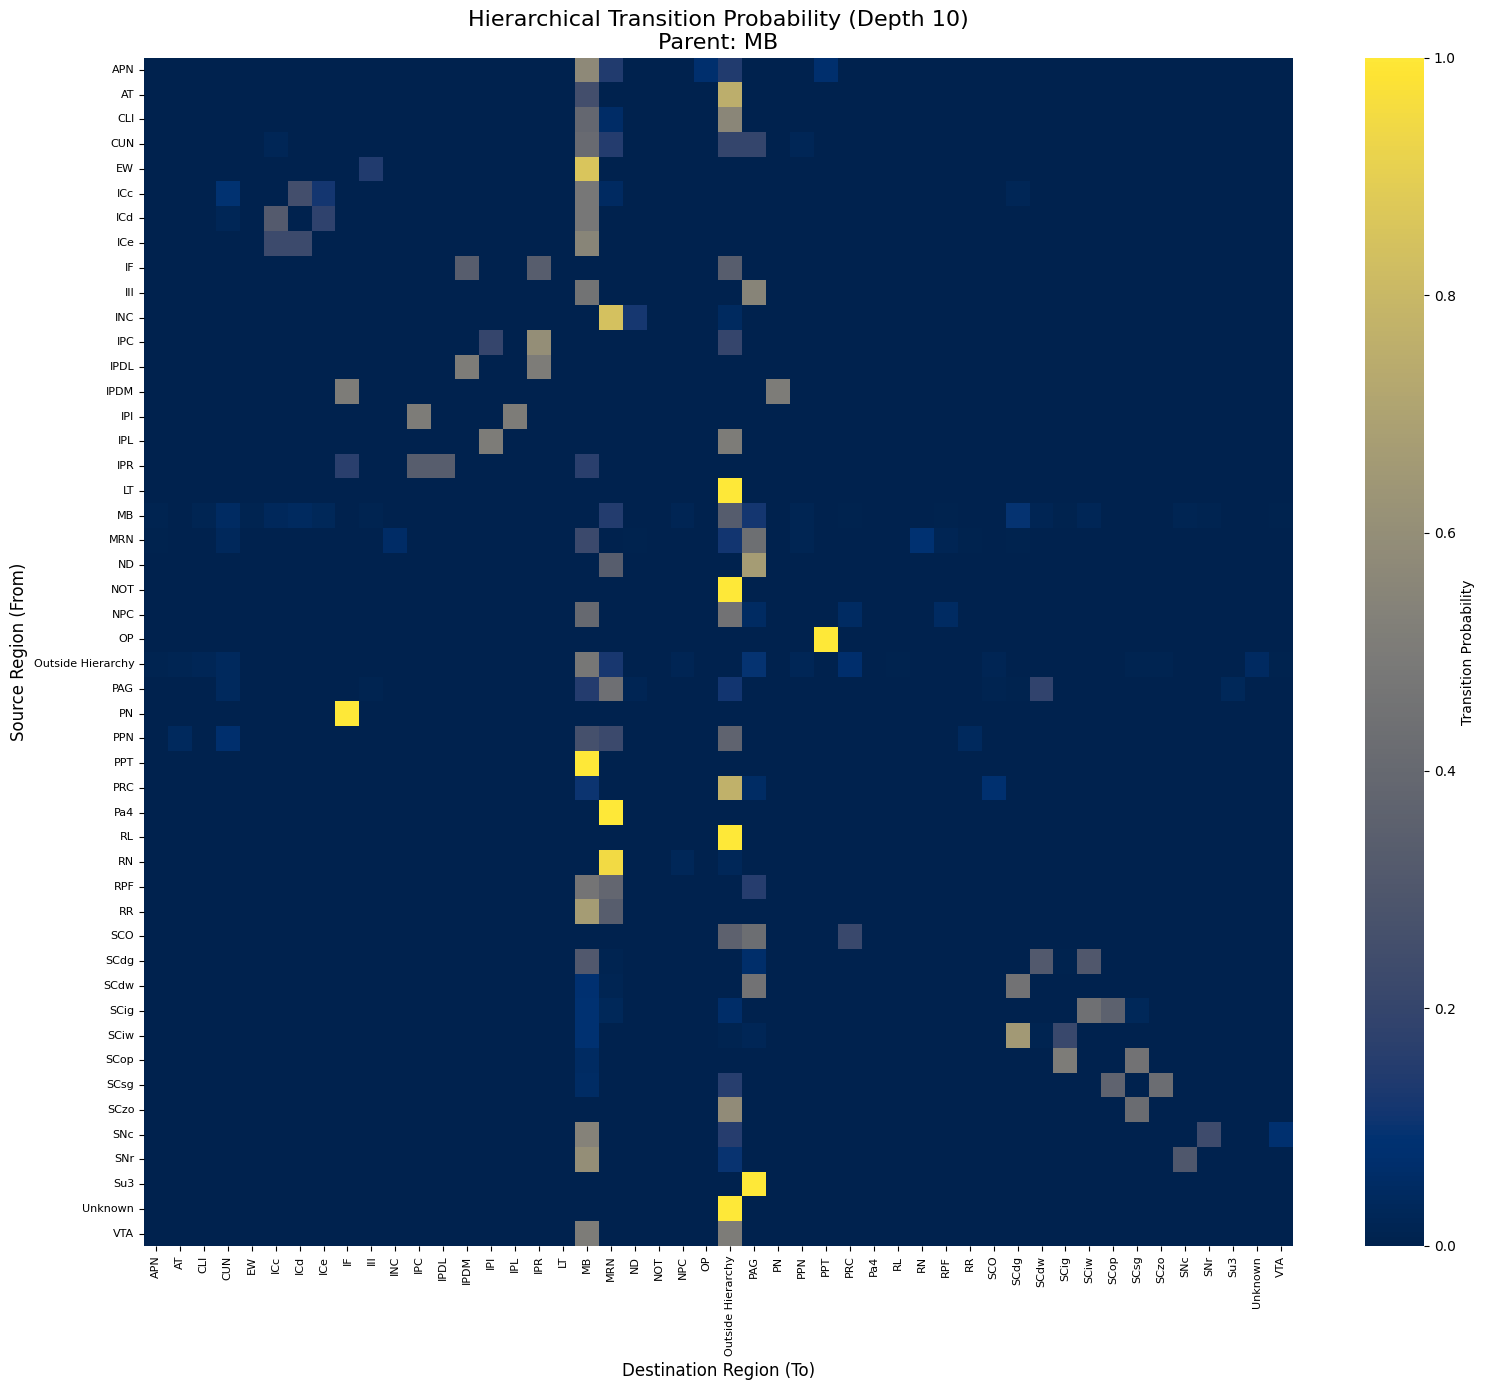

In [59]:
# Run the function
create_hierarchical_transition_matrix(coord_csv=new_output_file_coordinate, parent_region='MB', max_depth=10, cmap="cividis")